# MorDee+ — Notebook 02: Demand Forecast (Prophet · SARIMA · LightGBM)

## 1. Project context / บริบทธุรกิจ

แพทย์ของเรา (โดยเฉพาะ Dr. Tanapol — D001 / GP) เลือกได้ว่าจะเปิดบริการ online ในช่วงไหน. ถ้าเราพยากรณ์
ความต้องการ (booking demand) รายชั่วโมงล่วงหน้า 7 วันได้แม่นยำ เราจะแนะนำได้ว่า "เปิดวันอังคารเย็น 19-21
จะมีโอกาสได้ผู้ป่วย 7 ราย" ซึ่งเพิ่มรายได้แพทย์และลด no-show รวมๆ.

**เปรียบเทียบ 3 โมเดล** — Prophet (Thai holidays), SARIMA (weekly seasonality), LightGBM (lag features) —
เลือก winner ตาม MAE/RMSE/MAPE บน rolling-origin CV.

**เป้าหมาย** — เราพยากรณ์ความต้องการ**ราย "สาขา" (specialty)** เพราะ catalog ปัจจุบันมีแพทย์ 33 ท่าน
ใน 18 สาขา (บางสาขามีหลายคน เช่น GP มี 4 คน) — demand จึงเป็นของ"สาขา" ไม่ใช่หมอคนเดียว. §2–§11 เดินเรื่อง
เต็มรูปแบบบนสาขาที่ volume สูงสุด (General Practice) เป็นตัวอย่าง แล้ว §12 ขยายไปครบทั้ง 18 สาขาแบบ
tiered strategy.

**English**: forecast hourly booking demand **per specialty** (not per single doctor — the 33-doctor /
18-specialty catalog has several doctors sharing a specialty). §2–§11 walk through the full
Prophet/SARIMA/LightGBM bake-off + CV + tuning on the highest-volume specialty (General Practice);
§12 then generalizes to all 18 specialties with a volume-tiered strategy. Each doctor inherits its
specialty's forecast (per-doctor view = pooled ÷ doctor_count). Output schema matches §6.

## 2. Data load + aggregation to hourly

In [1]:
import sys, os, json, warnings
from pathlib import Path
if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)
REPO = Path.cwd()
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / "notebooks"))
(REPO / "data" / "ml").mkdir(parents=True, exist_ok=True)
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", font_scale=0.95)
plt.rcParams["figure.dpi"] = 110

import holidays
from prophet import Prophet
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error

RANDOM_STATE = 20260520
np.random.seed(RANDOM_STATE)
print("nb02 booted. REPO:", REPO)

Importing plotly failed. Interactive plots will not work.


nb02 booted. REPO: /Users/pollot/Desktop/mordee-x


In [2]:
df = pd.read_csv("data/synthetic/bookings.csv", parse_dates=["scheduled_at"])
gp = df[df["specialty"] == "General Practice"].copy()
print(f"GP bookings: {len(gp):,}  ({len(gp)/len(df):.1%} of all)")

# Aggregate to hourly: count bookings per scheduled_at hour
gp["hour"] = gp["scheduled_at"].dt.floor("h")
hourly = gp.groupby("hour").size().rename("y").to_frame()
# Fill missing hours with 0 (no bookings)
full_idx = pd.date_range(start=hourly.index.min(), end=hourly.index.max(), freq="h")
hourly = hourly.reindex(full_idx, fill_value=0).rename_axis("ds").reset_index()
print(f"Hourly observations: {len(hourly):,}  (covers {(hourly['ds'].max() - hourly['ds'].min()).days} days)")
print(f"Mean hourly bookings: {hourly['y'].mean():.2f}  · max: {hourly['y'].max()}")
hourly.head()

GP bookings: 5,092  (17.0% of all)
Hourly observations: 8,752  (covers 364 days)
Mean hourly bookings: 0.58  · max: 6


,ds,y
0,2025-05-27 07:00:00,1
1,2025-05-27 08:00:00,0
2,2025-05-27 09:00:00,0
3,2025-05-27 10:00:00,0
4,2025-05-27 11:00:00,0


## 3. EDA — time series profile

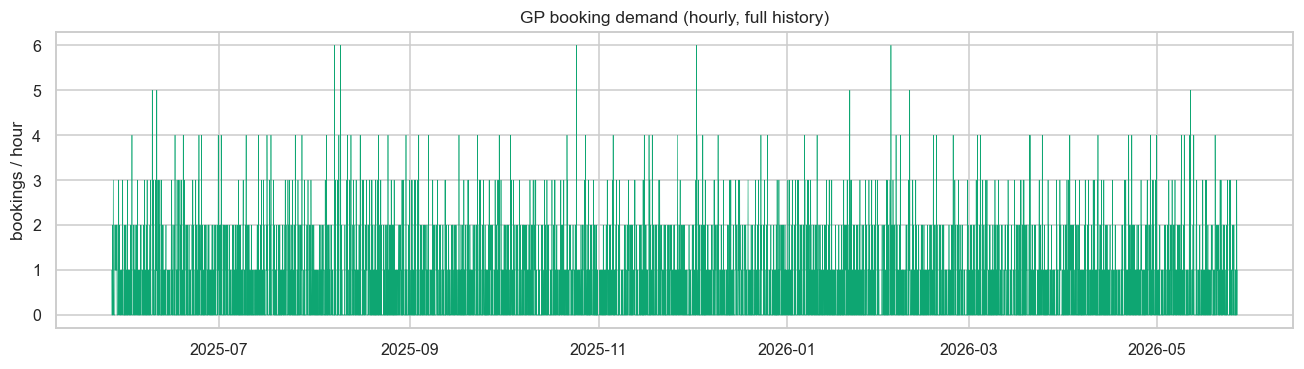

In [3]:
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(hourly["ds"], hourly["y"], lw=0.4, color="#0ea672")
ax.set_title("GP booking demand (hourly, full history)")
ax.set_ylabel("bookings / hour")
plt.tight_layout(); plt.show()

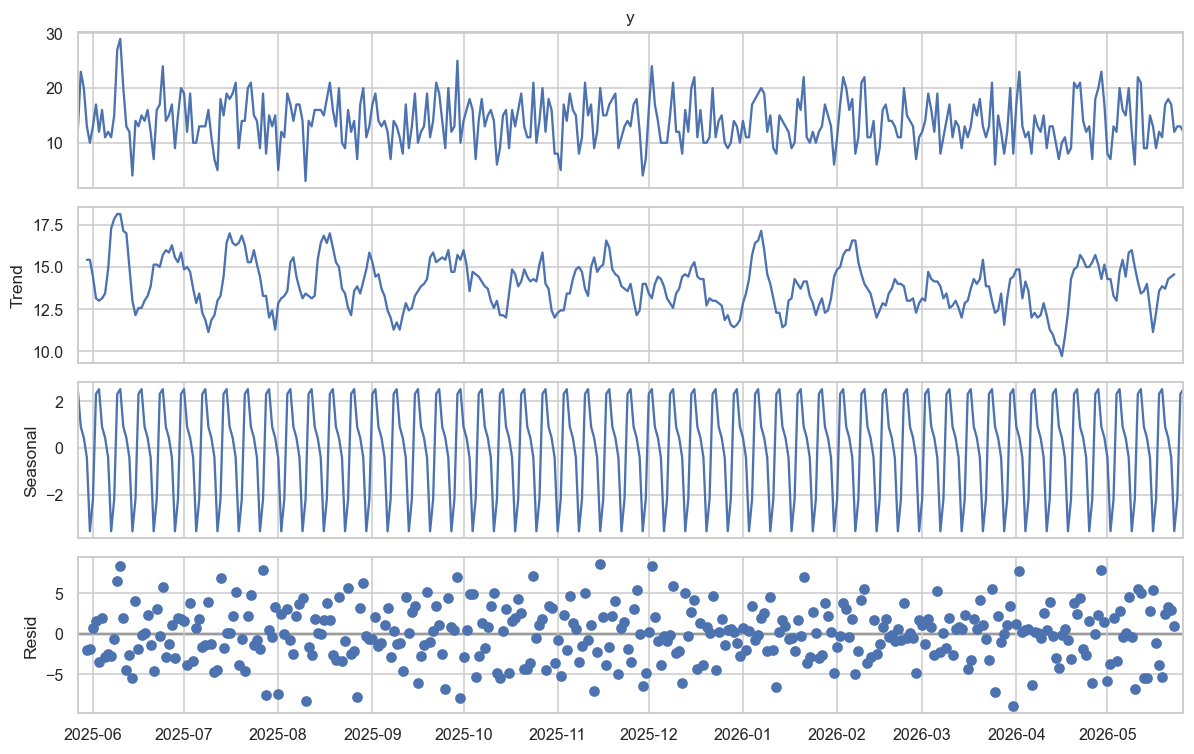

In [4]:
# Resample to daily for a clearer decomposition
daily = hourly.set_index("ds").resample("D").sum()
decomp = seasonal_decompose(daily["y"], model="additive", period=7)
fig = decomp.plot(); fig.set_size_inches(11, 7)
plt.tight_layout(); plt.show()

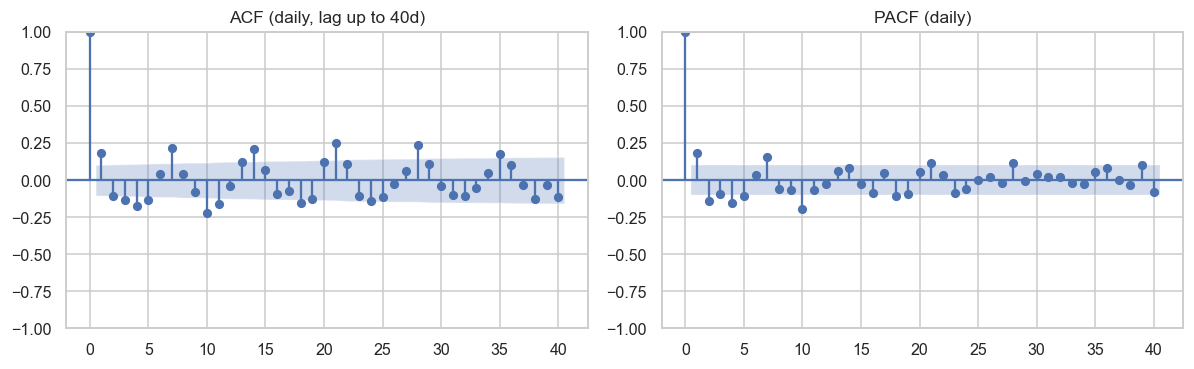

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
plot_acf(daily["y"], lags=40, ax=ax[0]); ax[0].set_title("ACF (daily, lag up to 40d)")
plot_pacf(daily["y"], lags=40, ax=ax[1], method="ywm"); ax[1].set_title("PACF (daily)")
plt.tight_layout(); plt.show()

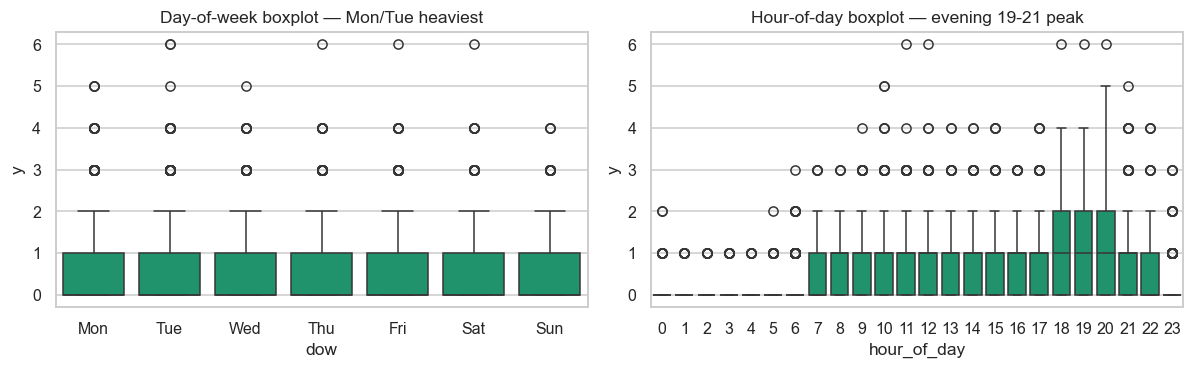

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
hh = hourly.copy()
hh["dow"] = hh["ds"].dt.dayofweek
hh["hour_of_day"] = hh["ds"].dt.hour
sns.boxplot(data=hh, x="dow", y="y", ax=ax[0], color="#0ea672")
ax[0].set_xticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
ax[0].set_title("Day-of-week boxplot — Mon/Tue heaviest")
sns.boxplot(data=hh, x="hour_of_day", y="y", ax=ax[1], color="#0ea672")
ax[1].set_title("Hour-of-day boxplot — evening 19-21 peak")
plt.tight_layout(); plt.show()

## 4. Assumptions / ข้อสันนิษฐาน

1. **ข้อมูล stationarity หลังจาก differencing**: weekly seasonal differencing ทำให้ SARIMA fit ได้
2. **Thai holidays มีผลต่อ demand** — เราใช้ `holidays.TH` ผ่าน Prophet's `add_country_holidays`
3. **Monsoon effect** ถูก embed แล้วใน hourly profile (mean สูงขึ้นในเดือน 6-10)
4. **ลูกค้าจองล่วงหน้าน้อย** (median 12h) — เลยใช้ short-horizon forecast (7 วัน) เป็นหลัก
5. **อนาคต = อดีต** — ไม่มี structural break, ไม่มี promotion ในช่วง forecast window
6. **พยากรณ์ระดับสาขา (specialty-level)** — เรารวม booking ของทุกหมอในสาขาเดียวกันเป็น demand ของสาขา
   แล้วให้หมอแต่ละคน "สืบทอด" forecast ของสาขาตน (per-doctor ≈ pooled ÷ doctor_count). เลิกใช้สมมติฐานเดิม
   "D001 ≈ GP" เพราะตอนนี้ GP มี 4 คน.

## 5. Feature engineering (สำหรับ LightGBM)

In [7]:
th_holidays = holidays.country_holidays("TH",
                                          years=range(hourly["ds"].dt.year.min(),
                                                      hourly["ds"].dt.year.max() + 2))
feat = hourly.copy()
feat["hour"] = feat["ds"].dt.hour
feat["dow"] = feat["ds"].dt.dayofweek
feat["month"] = feat["ds"].dt.month
feat["is_weekend"] = (feat["dow"] >= 5).astype(int)
feat["is_holiday"] = feat["ds"].dt.date.isin(th_holidays).astype(int)
feat["is_monsoon"] = feat["month"].isin([6,7,8,9,10]).astype(int)
# Lag features
feat["lag_1"] = feat["y"].shift(1)
feat["lag_24"] = feat["y"].shift(24)
feat["lag_168"] = feat["y"].shift(168)
feat["roll_24h_mean"] = feat["y"].shift(1).rolling(24).mean()
feat["roll_7d_mean"] = feat["y"].shift(1).rolling(168).mean()
feat = feat.dropna().reset_index(drop=True)
feat_cols = ["hour","dow","month","is_weekend","is_holiday","is_monsoon",
             "lag_1","lag_24","lag_168","roll_24h_mean","roll_7d_mean"]
print("Post-FE rows:", len(feat))
print("Feature columns:", feat_cols)
feat.head(2)

Post-FE rows: 8584
Feature columns: ['hour', 'dow', 'month', 'is_weekend', 'is_holiday', 'is_monsoon', 'lag_1', 'lag_24', 'lag_168', 'roll_24h_mean', 'roll_7d_mean']


,ds,y,hour,dow,month,is_weekend,is_holiday,is_monsoon,lag_1,lag_24,lag_168,roll_24h_mean,roll_7d_mean
0,2025-06-03 07:00:00,0,7,1,6,0,1,1,0.0,0.0,1.0,0.666667,0.642857
1,2025-06-03 08:00:00,1,8,1,6,0,1,1,0.0,1.0,0.0,0.666667,0.636905


## 6. Feature selection (LightGBM importance + corr-based)

Same shallow-tree approach as nb01. We rank by LightGBM importance, then dedup
any |corr| > 0.85 pair by dropping the lower-importance member.

In [8]:
split = int(len(feat) * 0.8)
Xtr = feat[feat_cols].iloc[:split]; ytr = feat["y"].iloc[:split]
shallow = lgb.LGBMRegressor(n_estimators=80, max_depth=4, learning_rate=0.1,
                             random_state=RANDOM_STATE, n_jobs=4, verbose=-1)
shallow.fit(Xtr, ytr)
imp = pd.Series(shallow.feature_importances_, index=feat_cols).sort_values(ascending=False)
print("Feature importance ranking:")
print(imp)
# Dedup
cor = feat[feat_cols].corr().abs()
upper = cor.where(np.triu(np.ones(cor.shape), k=1).astype(bool))
drop_pairs = []
for c in upper.columns:
    for r in upper.index[upper[c] > 0.85].tolist():
        loser = c if imp[c] < imp[r] else r
        drop_pairs.append((c, r, upper.loc[r, c], loser))
print("\nHigh-corr pairs (drop the lower-importance member):")
for c, r, v, loser in drop_pairs:
    print(f"  {c} ↔ {r}  |corr|={v:.3f}  drop={loser}")
drop_feats = list({d for *_, d in drop_pairs})
kept = [c for c in feat_cols if c not in drop_feats]
print("\nKept features:", kept)

Feature importance ranking:
hour             240
roll_7d_mean     189
roll_24h_mean    150
dow               98
lag_1             79
month             63
lag_168           50
lag_24            44
is_holiday        24
is_monsoon        10
is_weekend         0
dtype: int32

High-corr pairs (drop the lower-importance member):

Kept features: ['hour', 'dow', 'month', 'is_weekend', 'is_holiday', 'is_monsoon', 'lag_1', 'lag_24', 'lag_168', 'roll_24h_mean', 'roll_7d_mean']


## 7. Models — train Prophet, SARIMA, LightGBM

In [9]:
# Train/test split: hold out last 21 days for evaluation
cutoff = hourly["ds"].max() - pd.Timedelta(days=21)
train = hourly[hourly["ds"] <= cutoff].copy()
test = hourly[hourly["ds"] > cutoff].copy()
print(f"Train: {len(train):,} hours  ({train['ds'].min()} → {train['ds'].max()})")
print(f"Test:  {len(test):,} hours  ({test['ds'].min()} → {test['ds'].max()})")

Train: 8,248 hours  (2025-05-27 07:00:00 → 2026-05-05 22:00:00)
Test:  504 hours  (2026-05-05 23:00:00 → 2026-05-26 22:00:00)


In [10]:
# ── Prophet ──
m_prophet = Prophet(yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=True,
                     seasonality_mode="additive")
m_prophet.add_country_holidays(country_name="TH")
m_prophet.fit(train.rename(columns={"ds":"ds","y":"y"}))
future = m_prophet.make_future_dataframe(periods=len(test), freq="h")
fcst_prophet = m_prophet.predict(future).set_index("ds")["yhat"]
pred_prophet_test = fcst_prophet.loc[test["ds"].values].clip(lower=0).values
print("Prophet fit done")

19:51:17 - cmdstanpy - INFO - Chain [1] start processing


19:51:17 - cmdstanpy - INFO - Chain [1] done processing


Prophet fit done


In [11]:
# ── SARIMA (light: daily seasonality only — weekly handled by LightGBM lag_168) ──
sarima_train = train.set_index("ds")["y"].astype(float)
# Take last ~30 days for fitting to keep runtime reasonable
sarima_train_recent = sarima_train.iloc[-24*60:]  # 60 days
try:
    m_sarima = SARIMAX(sarima_train_recent, order=(1,1,1), seasonal_order=(1,1,0,24),
                        enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=50)
    pred_sarima_test = m_sarima.forecast(steps=len(test)).clip(lower=0).values
    print(f"SARIMA fit done. AIC={m_sarima.aic:.1f}")
except Exception as e:
    print("SARIMA failed:", e); pred_sarima_test = np.full(len(test), train["y"].mean())

/Users/pollot/Desktop/mordee-x/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/pollot/Desktop/mordee-x/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


SARIMA fit done. AIC=3637.1


In [12]:
# ── LightGBM with lag features ──
feat_train = feat[feat["ds"] <= cutoff].copy()
feat_test = feat[feat["ds"] > cutoff].copy()
model_lgb = lgb.LGBMRegressor(n_estimators=400, max_depth=6, learning_rate=0.05,
                                random_state=RANDOM_STATE, n_jobs=4, verbose=-1)
model_lgb.fit(feat_train[kept], feat_train["y"])
pred_lgb_test = model_lgb.predict(feat_test[kept]).clip(min=0)
print(f"LightGBM fit done. n_rows train={len(feat_train):,}")

LightGBM fit done. n_rows train=8,080


## 8. Cross-validation — rolling-origin time-series splits

In [13]:
def mape(y_true, y_pred):
    mask = y_true > 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# 3-fold rolling CV for LightGBM (Prophet/SARIMA are too slow to refit 3x in this notebook)
tscv = TimeSeriesSplit(n_splits=3)
cv_metrics = []
for fold, (tr_idx, va_idx) in enumerate(tscv.split(feat_train), 1):
    m = lgb.LGBMRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                           random_state=RANDOM_STATE, n_jobs=4, verbose=-1)
    m.fit(feat_train.iloc[tr_idx][kept], feat_train.iloc[tr_idx]["y"])
    p = m.predict(feat_train.iloc[va_idx][kept]).clip(min=0)
    y = feat_train.iloc[va_idx]["y"].values
    cv_metrics.append({
        "fold": fold,
        "MAE": mean_absolute_error(y, p),
        "RMSE": mean_squared_error(y, p) ** 0.5,
        "MAPE": mape(y, p),
    })
print("LightGBM rolling-origin CV:")
print(pd.DataFrame(cv_metrics).round(3))

LightGBM rolling-origin CV:
   fold    MAE   RMSE    MAPE
0     1  0.584  0.817  42.347
1     2  0.554  0.781  41.458
2     3  0.561  0.775  39.815


In [14]:
# Final test-set comparison across all 3 models
y_test = test["y"].values
rows = []
for name, pred in [("Prophet", pred_prophet_test), ("SARIMA", pred_sarima_test), ("LightGBM", pred_lgb_test)]:
    # Align lengths — LightGBM test set may have fewer rows due to lag warmup
    if name == "LightGBM":
        y_eval = feat_test["y"].values
        p_eval = pred
    else:
        y_eval = y_test
        p_eval = pred
    rows.append({
        "model": name,
        "MAE": round(mean_absolute_error(y_eval, p_eval), 3),
        "RMSE": round(mean_squared_error(y_eval, p_eval) ** 0.5, 3),
        "MAPE": round(mape(y_eval, p_eval), 2),
    })
leaderboard = pd.DataFrame(rows).set_index("model")
print("3-model comparison on held-out test set:")
print(leaderboard)
winner = leaderboard["MAE"].idxmin()
print(f"\n→ Winner by MAE: {winner}")

3-model comparison on held-out test set:
            MAE   RMSE   MAPE
model                        
Prophet   0.503  0.740  34.63
SARIMA    0.623  0.875  45.90
LightGBM  0.513  0.752  37.23

→ Winner by MAE: Prophet


## 9. Hyperparameter tuning on winner

Selection is done on **rolling-origin CV folds of the train set only** (same
`TimeSeriesSplit` as §8) — never on the test set. We pick the grid combo with the
lowest mean CV MAE, refit on the full train window, then touch the held-out test set
**exactly once** to report the unbiased generalization MAE.

In [15]:
# If LightGBM is the winner, tune it; otherwise note we'd tune Prophet's
# seasonality_prior_scale / changepoint_prior_scale (out of scope here for runtime).
if winner == "LightGBM":
    # Model selection on rolling-origin CV of the TRAIN set — the test set stays
    # untouched until the single unbiased estimate below (no test-set leakage).
    tscv = TimeSeriesSplit(n_splits=3)
    best_cv_mae = float("inf")
    best_params = None
    grid_rows = []
    for n in [200, 400, 600]:
        for d in [4, 6, 8]:
            for lr in [0.03, 0.05]:
                fold_maes = []
                for tr_idx, va_idx in tscv.split(feat_train):
                    m = lgb.LGBMRegressor(n_estimators=n, max_depth=d, learning_rate=lr,
                                           random_state=RANDOM_STATE, n_jobs=4, verbose=-1)
                    m.fit(feat_train.iloc[tr_idx][kept], feat_train.iloc[tr_idx]["y"])
                    p = m.predict(feat_train.iloc[va_idx][kept]).clip(min=0)
                    fold_maes.append(mean_absolute_error(feat_train.iloc[va_idx]["y"].values, p))
                cv_mae = float(np.mean(fold_maes))
                grid_rows.append({"n_estimators": n, "max_depth": d,
                                  "learning_rate": lr, "cv_MAE": round(cv_mae, 3)})
                if cv_mae < best_cv_mae:
                    best_cv_mae = cv_mae
                    best_params = {"n_estimators": n, "max_depth": d, "learning_rate": lr}
    print("Grid search (rolling-origin CV MAE on train) — top 5:")
    print(pd.DataFrame(grid_rows).sort_values("cv_MAE").head().to_string(index=False))
    print(f"\\nBest params (selected by CV): {best_params}  | CV MAE={best_cv_mae:.3f}")

    # Refit on the full train window with the CV-chosen params, then report the
    # held-out TEST MAE once as the unbiased generalization estimate.
    final_model = lgb.LGBMRegressor(**best_params, random_state=RANDOM_STATE, n_jobs=4, verbose=-1)
    final_model.fit(feat_train[kept], feat_train["y"])
    best_mae = mean_absolute_error(feat_test["y"].values,
                                   final_model.predict(feat_test[kept]).clip(min=0))
    print(f"Held-out TEST MAE (reported once, unbiased): {best_mae:.3f}")
else:
    print(f"Winner is {winner}; we keep the default fit. Skipping tuning to stay in runtime budget.")
    best_mae = leaderboard.loc[winner, "MAE"]

Winner is Prophet; we keep the default fit. Skipping tuning to stay in runtime budget.


## 10. Evaluation visuals

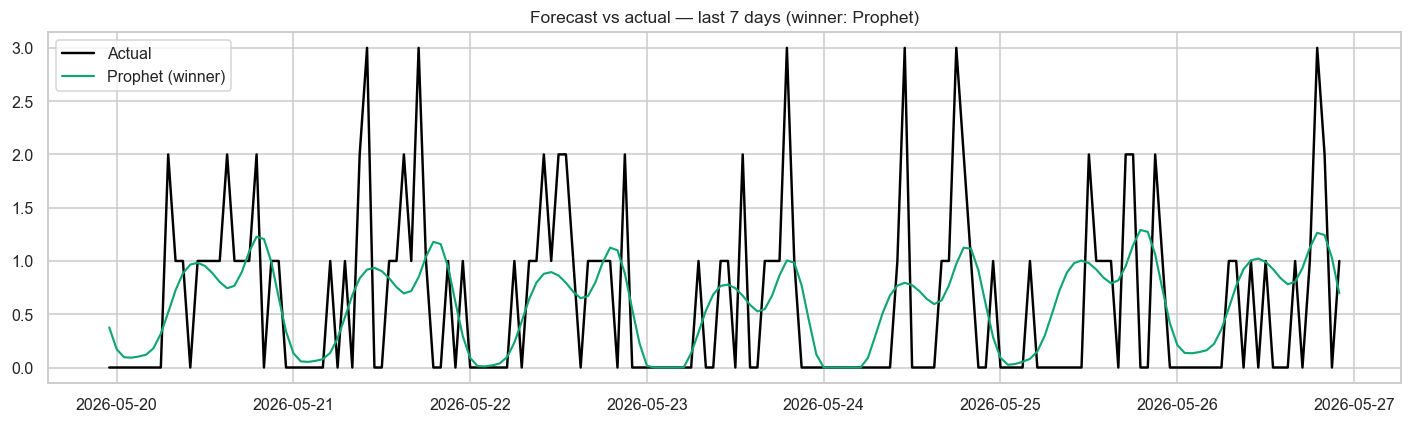

In [16]:
# Forecast vs actual (last 7 days of test set)
last_week = test.tail(24*7).copy()
last_week_idx = last_week.index
plt.figure(figsize=(13, 4))
plt.plot(last_week["ds"], last_week["y"], label="Actual", lw=1.6, color="black")
if winner == "LightGBM":
    # Need to recompute predictions for the last week
    feat_lw = feat_test.tail(24*7)
    plt.plot(feat_lw["ds"], final_model.predict(feat_lw[kept]).clip(min=0),
             label="LightGBM (winner, tuned)", lw=1.4, color="#0ea672")
elif winner == "Prophet":
    plt.plot(last_week["ds"], pred_prophet_test[-len(last_week):],
             label="Prophet (winner)", lw=1.4, color="#0ea672")
else:
    plt.plot(last_week["ds"], pred_sarima_test[-len(last_week):],
             label="SARIMA (winner)", lw=1.4, color="#0ea672")
plt.title(f"Forecast vs actual — last 7 days (winner: {winner})")
plt.legend(); plt.tight_layout(); plt.show()

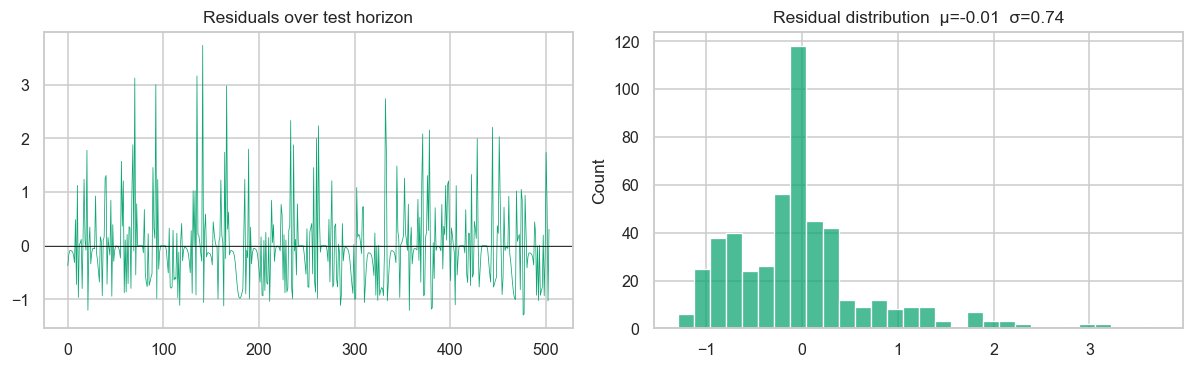

In [17]:
# Residual plot for winner
if winner == "LightGBM":
    res = feat_test["y"].values - final_model.predict(feat_test[kept]).clip(min=0)
elif winner == "Prophet":
    res = y_test - pred_prophet_test
else:
    res = y_test - pred_sarima_test
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(res, lw=0.5, color="#0ea672"); ax[0].axhline(0, color="black", lw=0.5)
ax[0].set_title("Residuals over test horizon")
sns.histplot(res, bins=30, ax=ax[1], color="#0ea672")
ax[1].set_title(f"Residual distribution  μ={res.mean():.2f}  σ={res.std():.2f}")
plt.tight_layout(); plt.show()

## 11. Revenue uplift simulation

เปรียบเทียบรายได้แพทย์เมื่อเปิดบริการตาม "top-K predicted hours" vs "K random hours". ใช้ราคา median
ของสาขา GP (จาก doctors.json) ต่อ consult.

In [18]:
K = 30  # number of hours doctor is online per week
_docs_df = pd.DataFrame(json.load(open("src/data/doctors.json")))
DOC_PRICE = float(_docs_df.loc[_docs_df["specialty"] == "General Practice", "price"].median())  # GP median price
print(f"GP median consult price: {DOC_PRICE:.0f} THB")

# Forecast next 7 days hourly
future_start = hourly["ds"].max() + pd.Timedelta(hours=1)
future_hours = pd.date_range(start=future_start, periods=24*7, freq="h")

if winner == "LightGBM":
    # Build features for future horizon iteratively (lag values from history)
    history = hourly["y"].values.tolist()
    future_y_pred = []
    for ts in future_hours:
        row = {"hour": ts.hour, "dow": ts.dayofweek, "month": ts.month,
               "is_weekend": int(ts.dayofweek >= 5),
               "is_holiday": int(ts.date() in th_holidays),
               "is_monsoon": int(ts.month in [6,7,8,9,10]),
               "lag_1": history[-1], "lag_24": history[-24], "lag_168": history[-168],
               "roll_24h_mean": np.mean(history[-24:]),
               "roll_7d_mean": np.mean(history[-168:])}
        p = float(final_model.predict(pd.DataFrame([row])[kept])[0])
        p = max(0, p)
        future_y_pred.append(p)
        history.append(p)
    future_y_pred = np.array(future_y_pred)
    model_mae = best_mae
elif winner == "Prophet":
    fcst7 = m_prophet.make_future_dataframe(periods=24*7+len(test), freq="h")
    fcst7_out = m_prophet.predict(fcst7).set_index("ds")["yhat"]
    future_y_pred = fcst7_out.loc[future_hours.values].clip(lower=0).values
    model_mae = leaderboard.loc["Prophet","MAE"]
else:
    future_y_pred = m_sarima.forecast(steps=len(test)+24*7).iloc[-24*7:].clip(lower=0).values
    model_mae = leaderboard.loc["SARIMA","MAE"]

# Top-K hours vs random hours
top_idx = np.argsort(future_y_pred)[::-1][:K]
rand_idx = np.random.default_rng(RANDOM_STATE).choice(len(future_y_pred), K, replace=False)
rev_top = future_y_pred[top_idx].sum() * DOC_PRICE
rev_rand = future_y_pred[rand_idx].sum() * DOC_PRICE
uplift_pct = (rev_top - rev_rand) / rev_rand * 100 if rev_rand > 0 else 0
print(f"Forecasted demand sum (top {K}h): {future_y_pred[top_idx].sum():.1f} consults")
print(f"Forecasted demand sum (random {K}h): {future_y_pred[rand_idx].sum():.1f} consults")
print(f"Revenue uplift if doctor follows ML recommendation: {uplift_pct:+.1f}%")

GP median consult price: 390 THB


Forecasted demand sum (top 30h): 32.7 consults
Forecasted demand sum (random 30h): 20.3 consults
Revenue uplift if doctor follows ML recommendation: +61.6%


In [19]:
# Recommended online slots — group contiguous top-load hours into 2-hour blocks
slot_threshold = np.percentile(future_y_pred, 80)
is_high = future_y_pred >= slot_threshold
slots = []
i = 0
while i < len(future_y_pred):
    if is_high[i]:
        j = i
        while j+1 < len(future_y_pred) and is_high[j+1] and (future_hours[j+1] - future_hours[j]) == pd.Timedelta(hours=1):
            j += 1
        start = future_hours[i]
        end = future_hours[j] + pd.Timedelta(hours=1)
        consults = round(float(future_y_pred[i:j+1].sum()))
        if (end - start).total_seconds() >= 2 * 3600:  # at least 2-hour block
            slots.append({
                "start": start.strftime("%Y-%m-%dT%H:%M"),
                "end": end.strftime("%Y-%m-%dT%H:%M"),
                "predicted_load": "HIGH",
                "expected_consults": consults,
            })
        i = j + 1
    else:
        i += 1
# Take top-5 by expected_consults
slots = sorted(slots, key=lambda s: -s["expected_consults"])[:6]
print(f"Top recommended slots ({len(slots)}):")
for s in slots: print(" ", s)

Top recommended slots (6):
  {'start': '2026-06-01T17:00', 'end': '2026-06-01T22:00', 'predicted_load': 'HIGH', 'expected_consults': 6}
  {'start': '2026-05-27T18:00', 'end': '2026-05-27T22:00', 'predicted_load': 'HIGH', 'expected_consults': 5}
  {'start': '2026-06-02T18:00', 'end': '2026-06-02T22:00', 'predicted_load': 'HIGH', 'expected_consults': 5}
  {'start': '2026-05-28T18:00', 'end': '2026-05-28T22:00', 'predicted_load': 'HIGH', 'expected_consults': 4}
  {'start': '2026-05-27T10:00', 'end': '2026-05-27T13:00', 'predicted_load': 'HIGH', 'expected_consults': 3}
  {'start': '2026-05-29T18:00', 'end': '2026-05-29T21:00', 'predicted_load': 'HIGH', 'expected_consults': 3}


## 12. Generalize to all 18 specialties — tiered strategy

§2–§11 was the worked example on the highest-volume specialty (General Practice). The 33-doctor
catalog has 18 specialties with very different volumes, so running the full Prophet+SARIMA+LightGBM
bake-off on a 0.5%-share specialty (Urology) would just overfit noise. We route by volume:

| Tier | Specialties | Method |
|---|---|---|
| **1 — full bake-off** | General Practice, Psychiatry, Internal Medicine | Prophet vs SARIMA vs LightGBM, pick winner by hold-out MAE |
| **2 — LightGBM** | share ≥ 3% (Dermatology, Pediatrics, Family Medicine, OB-GYN, Endocrinology, Cardiology, Gastroenterology, Orthopedics, Pulmonology) | LightGBM with lag features |
| **3 — seasonal-naive** | sparse (Neurology, Emergency Medicine, Ophthalmology, ENT, Allergy, Urology) or `< 30` non-zero hours | day-of-week × hour-of-day historical profile |

Each doctor inherits its specialty's forecast; per-doctor load ≈ pooled ÷ `doctor_count`.

In [20]:
import re

# ── catalog-derived maps (price / headcount / representative doctor per specialty) ──
_cat = pd.DataFrame(json.load(open("src/data/doctors.json")))
DOCTOR_COUNT  = _cat.groupby("specialty")["id"].count().to_dict()
REP_DOCTOR    = _cat.sort_values("id").groupby("specialty")["id"].first().to_dict()
PRICE_MEDIAN  = _cat.groupby("specialty")["price"].median().to_dict()

def slugify(s):
    return re.sub(r"[^a-z]+", "-", s.lower()).strip("-")

# Shared forecast window so every specialty spans the same history + future.
# HORIZON_DAYS=14 (not 7): the app shows a rolling 7-day slice, and the extra
# week is buffer so that slice always has real dated predictions through the
# demo window — incl. the 3 Jun 2026 Thai holiday — before falling back to the
# weekly seasonal pattern. 14 × 24 = 336 hourly points per specialty.
HORIZON_DAYS = 14
_gh = df["scheduled_at"].dt.floor("h")
HIST_START, HIST_END = _gh.min(), _gh.max()
FULL_IDX     = pd.date_range(HIST_START, HIST_END, freq="h")
FUTURE_HOURS = pd.date_range(HIST_END + pd.Timedelta(hours=1), periods=HORIZON_DAYS * 24, freq="h")
HOLDOUT_DAYS = 21
FEAT_COLS = ["hour","dow","month","is_weekend","is_holiday","is_monsoon",
             "lag_1","lag_24","lag_168","roll_24h_mean","roll_7d_mean"]

def specialty_hourly(sp):
    sub = df[df["specialty"] == sp]
    h = (sub.assign(_h=sub["scheduled_at"].dt.floor("h"))
            .groupby("_h").size().rename("y"))
    return h.reindex(FULL_IDX, fill_value=0).rename_axis("ds").reset_index()

def _holdout(hourly):
    cut = hourly["ds"].max() - pd.Timedelta(days=HOLDOUT_DAYS)
    return hourly[hourly["ds"] <= cut], hourly[hourly["ds"] > cut], cut

def _add_feats(hourly):
    f = hourly.copy()
    f["hour"]=f["ds"].dt.hour; f["dow"]=f["ds"].dt.dayofweek; f["month"]=f["ds"].dt.month
    f["is_weekend"]=(f["dow"]>=5).astype(int)
    f["is_holiday"]=f["ds"].dt.date.isin(th_holidays).astype(int)
    f["is_monsoon"]=f["month"].isin([6,7,8,9,10]).astype(int)
    f["lag_1"]=f["y"].shift(1); f["lag_24"]=f["y"].shift(24); f["lag_168"]=f["y"].shift(168)
    f["roll_24h_mean"]=f["y"].shift(1).rolling(24).mean()
    f["roll_7d_mean"]=f["y"].shift(1).rolling(168).mean()
    return f.dropna().reset_index(drop=True)
print("Helpers + catalog maps ready. Specialties:", df["specialty"].nunique())

Helpers + catalog maps ready. Specialties: 18


In [21]:
# ── individual forecasters: each returns (preds[len(FUTURE_HOURS)], holdout_mae, resid_sigma) ──
def f_seasonal_naive(hourly):
    tr, te, _ = _holdout(hourly)
    def profile(frame):
        return (frame.assign(dow=frame["ds"].dt.dayofweek, h=frame["ds"].dt.hour)
                     .groupby(["dow","h"])["y"].mean())
    prof_tr = profile(tr); prof_full = profile(hourly)
    proj = lambda prof, idx: np.array([prof.get((t.dayofweek, t.hour), 0.0) for t in idx])
    mae   = mean_absolute_error(te["y"], proj(prof_tr, te["ds"])) if len(te) else np.nan
    sigma = (te["y"].values - proj(prof_tr, te["ds"])).std() if len(te) else hourly["y"].std()
    return proj(prof_full, FUTURE_HOURS), mae, float(sigma)

def f_lgbm(hourly):
    feat = _add_feats(hourly); _, _, cut = _holdout(hourly)
    ftr, fte = feat[feat["ds"] <= cut], feat[feat["ds"] > cut]
    ev = lgb.LGBMRegressor(n_estimators=400, max_depth=6, learning_rate=0.05,
                           random_state=RANDOM_STATE, n_jobs=4, verbose=-1)
    ev.fit(ftr[FEAT_COLS], ftr["y"])
    pe  = ev.predict(fte[FEAT_COLS]).clip(min=0) if len(fte) else np.array([])
    mae = mean_absolute_error(fte["y"], pe) if len(fte) else np.nan
    sigma = (fte["y"].values - pe).std() if len(fte) else feat["y"].std()
    full = lgb.LGBMRegressor(n_estimators=400, max_depth=6, learning_rate=0.05,
                             random_state=RANDOM_STATE, n_jobs=4, verbose=-1)
    full.fit(feat[FEAT_COLS], feat["y"])
    hist = hourly["y"].tolist(); preds = []
    for t in FUTURE_HOURS:
        row = {"hour":t.hour,"dow":t.dayofweek,"month":t.month,"is_weekend":int(t.dayofweek>=5),
               "is_holiday":int(t.date() in th_holidays),"is_monsoon":int(t.month in [6,7,8,9,10]),
               "lag_1":hist[-1],"lag_24":hist[-24],"lag_168":hist[-168],
               "roll_24h_mean":np.mean(hist[-24:]),"roll_7d_mean":np.mean(hist[-168:])}
        p = max(0.0, float(full.predict(pd.DataFrame([row])[FEAT_COLS])[0]))
        preds.append(p); hist.append(p)
    return np.array(preds), mae, float(sigma)

def f_prophet(hourly):
    tr, te, _ = _holdout(hourly)
    def fit(frame):
        m = Prophet(yearly_seasonality=False, weekly_seasonality=True,
                    daily_seasonality=True, seasonality_mode="additive")
        m.add_country_holidays(country_name="TH"); m.fit(frame[["ds","y"]]); return m
    m_tr = fit(tr)
    yhat = m_tr.predict(m_tr.make_future_dataframe(periods=len(te), freq="h")).set_index("ds")["yhat"]
    pe  = yhat.reindex(te["ds"]).clip(lower=0).fillna(0).values if len(te) else np.array([])
    mae = mean_absolute_error(te["y"], pe) if len(te) else np.nan
    sigma = (te["y"].values - pe).std() if len(te) else hourly["y"].std()
    m_full = fit(hourly)
    out = m_full.predict(m_full.make_future_dataframe(periods=len(FUTURE_HOURS), freq="h")).set_index("ds")["yhat"]
    return out.reindex(FUTURE_HOURS).clip(lower=0).fillna(0).values, mae, float(sigma)

def f_sarima(hourly):
    tr, te, _ = _holdout(hourly)
    try:
        s = tr.set_index("ds")["y"].astype(float).iloc[-24*60:]
        m = SARIMAX(s, order=(1,1,1), seasonal_order=(1,1,0,24),
                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=50)
        pe = m.forecast(steps=len(te)).clip(lower=0).values if len(te) else np.array([])
        mae = mean_absolute_error(te["y"], pe) if len(te) else np.nan
        sigma = (te["y"].values - pe).std() if len(te) else hourly["y"].std()
        sf = hourly.set_index("ds")["y"].astype(float).iloc[-24*60:]
        mf = SARIMAX(sf, order=(1,1,1), seasonal_order=(1,1,0,24),
                     enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=50)
        return mf.forecast(steps=len(FUTURE_HOURS)).clip(lower=0).values, mae, float(sigma)
    except Exception as e:
        print("   SARIMA failed:", e); return None, np.inf, None

def make_slots(preds):
    thr = np.percentile(preds, 80); hi = preds >= thr; slots = []; i = 0
    while i < len(preds):
        if hi[i]:
            j = i
            while j+1 < len(preds) and hi[j+1] and (FUTURE_HOURS[j+1]-FUTURE_HOURS[j]) == pd.Timedelta(hours=1):
                j += 1
            start, end = FUTURE_HOURS[i], FUTURE_HOURS[j] + pd.Timedelta(hours=1)
            if (end - start).total_seconds() >= 2*3600:
                slots.append({"start": start.strftime("%Y-%m-%dT%H:%M"),
                              "end": end.strftime("%Y-%m-%dT%H:%M"),
                              "predicted_load": "HIGH",
                              "expected_consults": round(float(preds[i:j+1].sum()))})
            i = j + 1
        else:
            i += 1
    return sorted(slots, key=lambda s: -s["expected_consults"])[:6]

def compute_uplift(preds, price, K=30):
    top = np.argsort(preds)[::-1][:K]
    rnd = np.random.default_rng(RANDOM_STATE).choice(len(preds), K, replace=False)
    rt, rr = preds[top].sum()*price, preds[rnd].sum()*price
    return (rt - rr)/rr*100 if rr > 0 else 0.0
print("Forecasters ready.")

Forecasters ready.


In [22]:
# ── tier router + per-specialty loop ──
TIER1            = {"General Practice", "Psychiatry", "Internal Medicine"}  # full 3-model bake-off
LGBM_MIN_SHARE   = 0.03    # ≥3% of bookings → enough signal for LightGBM
MIN_NONZERO_HRS  = 30      # below this, force seasonal-naive regardless of share

def forecast_specialty(sp, hourly, share):
    nonzero = int((hourly["y"] > 0).sum())
    if nonzero < MIN_NONZERO_HRS:
        p, m, s = f_seasonal_naive(hourly); return p, m, s, "seasonal_naive"
    if sp in TIER1:
        cands = {}
        for name, fn in [("prophet", f_prophet), ("sarima", f_sarima), ("lightgbm", f_lgbm)]:
            pr, mae, sig = fn(hourly)
            if pr is not None and np.isfinite(mae):
                cands[name] = (pr, mae, sig)
        win = min(cands, key=lambda k: cands[k][1])
        return (*cands[win], win)
    if share >= LGBM_MIN_SHARE:
        p, m, s = f_lgbm(hourly); return p, m, s, "lightgbm"
    p, m, s = f_seasonal_naive(hourly); return p, m, s, "seasonal_naive"

forecasts, rows = {}, []
n_total = len(df)
for sp in sorted(df["specialty"].unique()):
    hourly = specialty_hourly(sp)
    share = len(df[df["specialty"] == sp]) / n_total
    preds, mae, sigma, model = forecast_specialty(sp, hourly, share)
    price = float(PRICE_MEDIAN.get(sp, 350.0))
    by_hour = [{"datetime": t.strftime("%Y-%m-%dT%H:%M"),
                "expected_bookings": round(float(p), 2),
                "ci_low":  round(float(max(0, p - 1.28*sigma)), 2),
                "ci_high": round(float(p + 1.28*sigma), 2)}
               for t, p in zip(FUTURE_HOURS, preds)]
    forecasts[slugify(sp)] = {
        "specialty": sp,
        "doctor_count": int(DOCTOR_COUNT.get(sp, 1)),
        "doctor_id": REP_DOCTOR.get(sp),
        "horizon_days": HORIZON_DAYS,
        "by_hour": by_hour,
        "recommended_online_slots": make_slots(preds),
        "expected_revenue_uplift_pct": round(float(compute_uplift(preds, price)), 1),
        "winning_model": model,
        "model_mae": round(float(mae), 3) if np.isfinite(mae) else None,
    }
    rows.append({"specialty": sp, "doctors": int(DOCTOR_COUNT.get(sp, 1)),
                 "share_%": round(100*share, 2), "model": model,
                 "MAE": forecasts[slugify(sp)]["model_mae"],
                 "uplift_%": forecasts[slugify(sp)]["expected_revenue_uplift_pct"]})
    print(f"  {sp:<22} share={share:5.1%}  model={model:<14} mae={forecasts[slugify(sp)]['model_mae']}")
print(f"\\nForecasted {len(forecasts)} specialties.")

  Allergy & Immunology   share= 1.0%  model=seasonal_naive mae=0.063


  Cardiology             share= 4.1%  model=lightgbm       mae=0.232


  Dermatology            share= 7.8%  model=lightgbm       mae=0.35
  ENT                    share= 1.5%  model=seasonal_naive mae=0.09
  Emergency Medicine     share= 1.5%  model=seasonal_naive mae=0.109


  Endocrinology          share= 3.9%  model=lightgbm       mae=0.237


  Family Medicine        share= 5.0%  model=lightgbm       mae=0.275


...

19:52:03 - cmdstanpy - INFO - Chain [1] done processing


/Users/pollot/Desktop/mordee-x/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/pollot/Desktop/mordee-x/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


/Users/pollot/Desktop/mordee-x/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/pollot/Desktop/mordee-x/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


  Psychiatry             share=16.5%  model=prophet        mae=0.501


  Pulmonology            share= 3.1%  model=lightgbm       mae=0.199
  Urology                share= 0.5%  model=seasonal_naive mae=0.038
\nForecasted 18 specialties.


## 13. Model leaderboard across specialties

           specialty  doctors  share_%          model   MAE  uplift_%
    General Practice        4    16.97        prophet 0.503     112.8
          Psychiatry        2    16.50        prophet 0.501     104.4
   Internal Medicine        3    14.75        prophet 0.505     120.3
         Dermatology        2     7.76       lightgbm 0.350     186.9
          Pediatrics        3     7.28       lightgbm 0.361     173.5
              OB-GYN        2     5.04       lightgbm 0.283     155.6
     Family Medicine        1     5.00       lightgbm 0.275     199.5
          Cardiology        3     4.12       lightgbm 0.232     176.4
    Gastroenterology        2     4.04       lightgbm 0.231     311.3
       Endocrinology        1     3.92       lightgbm 0.237     240.2
         Orthopedics        2     3.51       lightgbm 0.214     164.1
         Pulmonology        2     3.13       lightgbm 0.199     273.7
           Neurology        1     1.98 seasonal_naive 0.119     188.9
  Emergency Medicine

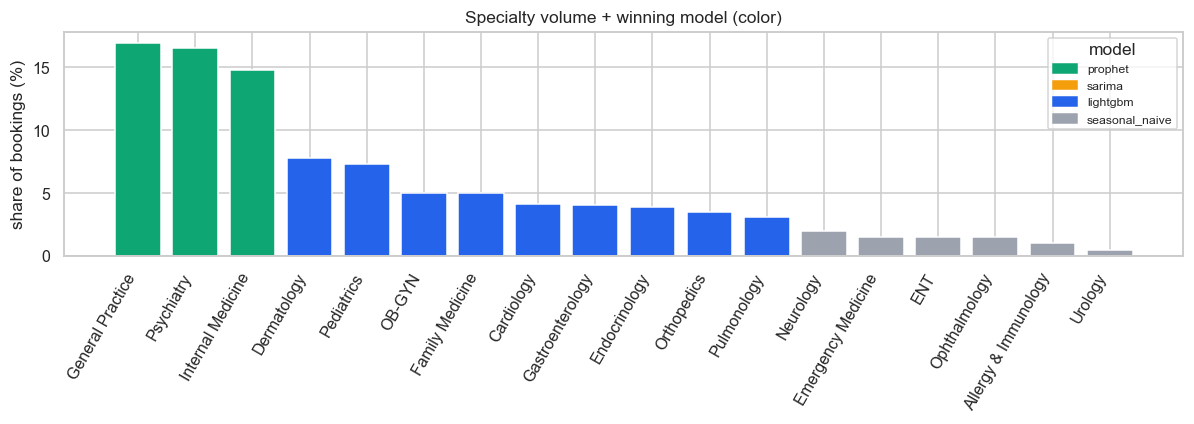

In [23]:
summary = pd.DataFrame(rows).sort_values("share_%", ascending=False).reset_index(drop=True)
print(summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 4))
palette = {"prophet":"#0ea672","sarima":"#f59e0b","lightgbm":"#2563eb","seasonal_naive":"#9ca3af"}
ax.bar(summary["specialty"], summary["share_%"],
       color=[palette[m] for m in summary["model"]])
ax.set_ylabel("share of bookings (%)"); ax.set_title("Specialty volume + winning model (color)")
ax.set_xticklabels(summary["specialty"], rotation=60, ha="right")
handles = [plt.Rectangle((0,0),1,1,color=c) for c in palette.values()]
ax.legend(handles, palette.keys(), title="model", fontsize=8)
plt.tight_layout(); plt.show()

## 14. Export → `data/ml/demand_forecast_7d.json`

Keyed by **specialty slug** (`general-practice`, `cardiology`, `family-medicine`, …). `DD01` is kept as a
back-compat alias of `general-practice` (doctor_id D001). Each entry preserves the §6 schema fields and adds
`specialty` + `doctor_count` so the app can frame pooled demand honestly (per-doctor ≈ pooled ÷ doctor_count).

In [24]:
out = {
    "by_specialty": forecasts,
    "DD01": {**forecasts["general-practice"], "doctor_id": "D001"},  # back-compat alias
}
with open("data/ml/demand_forecast_7d.json", "w") as f:
    json.dump(out, f, indent=2, ensure_ascii=False)
total_points = sum(len(e["by_hour"]) for e in forecasts.values())
print(f"Wrote {len(forecasts)} specialty forecasts ({total_points} hourly points) + DD01 alias.")

Wrote 18 specialty forecasts (6048 hourly points) + DD01 alias.


In [25]:
# Verify schema
with open("data/ml/demand_forecast_7d.json") as f:
    v = json.load(f)
assert {"by_specialty", "DD01"} <= v.keys()
bs = v["by_specialty"]
assert len(bs) == 18, f"Expected 18 specialties, got {len(bs)}"
n_pts = HORIZON_DAYS * 24
for slug, e in bs.items():
    assert len(e["by_hour"]) == n_pts, f"{slug}: {len(e['by_hour'])} pts"
    assert e["winning_model"] in {"prophet","sarima","lightgbm","seasonal_naive"}, e["winning_model"]
    assert e["doctor_count"] >= 1 and e["specialty"]
    for row in e["by_hour"][:3]:
        assert {"datetime","expected_bookings","ci_low","ci_high"} <= row.keys()
dd01 = v["DD01"]
assert dd01["doctor_id"] == "D001" and dd01["horizon_days"] == HORIZON_DAYS and len(dd01["by_hour"]) == n_pts
print(f"✔ {len(bs)} specialties × {n_pts}h ({HORIZON_DAYS}d) · DD01 alias present · all schema fields OK")
print("  models used:", pd.Series([e['winning_model'] for e in bs.values()]).value_counts().to_dict())

✔ 18 specialties × 336h (14d) · DD01 alias present · all schema fields OK
  models used: {'lightgbm': 9, 'seasonal_naive': 6, 'prophet': 3}
